Image loaded: shape=(1080, 1157), dtype=uint8
Intensity range: [0, 245]


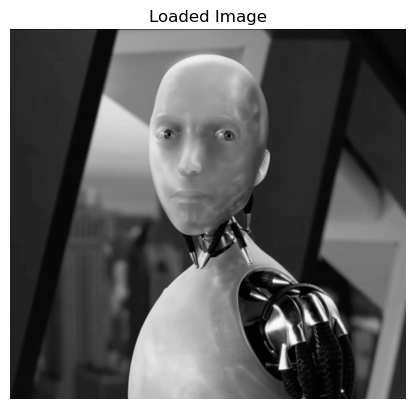

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

IMAGE_PATH = '/Users/230150/Desktop/robot.jpeg' 

img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"Could not load image at '{IMAGE_PATH}'. Please check the path.")

# Convert to grayscale for all transformations
test_image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Image loaded: shape={test_image.shape}, dtype={test_image.dtype}")
print(f"Intensity range: [{test_image.min()}, {test_image.max()}]")

plt.imshow(test_image, cmap='gray')
plt.title('Loaded Image')
plt.axis('off')
plt.show()

# Part 1 – Power Law Transformation (Gamma Correction)

### Challenge 1.1
Implement a function `gamma_correction(image, gamma)` from scratch.

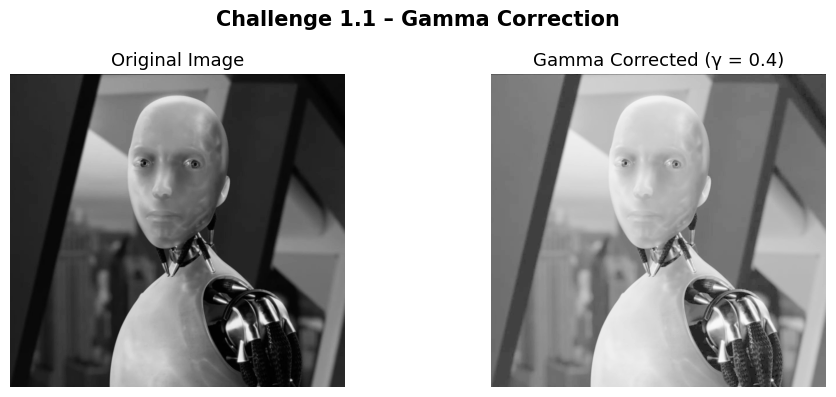

In [16]:
def gamma_correction(image, gamma):
    
    if not isinstance(image, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if gamma <= 0:
        raise ValueError("Gamma must be a positive value.")

    # Normalize to [0, 1]
    normalized = image.astype(np.float64) / 255.0

    # Apply power-law transformation
    corrected = np.power(normalized, gamma)

    # Scale back to [0, 255] and convert to uint8
    corrected_uint8 = np.clip(corrected * 255.0, 0, 255).astype(np.uint8)

    return corrected_uint8
    
gamma_val = 0.4
corrected = gamma_correction(test_image, gamma_val)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(test_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image', fontsize=13)
axes[0].axis('off')

axes[1].imshow(corrected, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Gamma Corrected (γ = {gamma_val})', fontsize=13)
axes[1].axis('off')

plt.suptitle('Challenge 1.1 – Gamma Correction', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('challenge_1_1.png', dpi=120, bbox_inches='tight')
plt.show()

### Challenge 1.2 – Gamma Curve Analysis

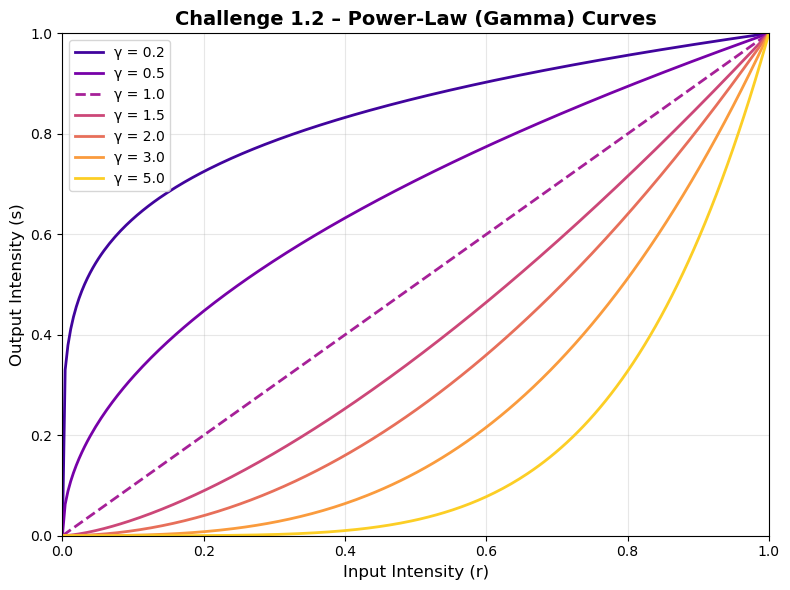

In [15]:
r = np.linspace(0, 1, 256)

gamma_values = [0.2, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(gamma_values)))

plt.figure(figsize=(8, 6))

for gamma, color in zip(gamma_values, colors):
    s = np.power(r, gamma)
    linestyle = '--' if gamma == 1.0 else '-'
    plt.plot(r, s, label=f'γ = {gamma}', color=color, linewidth=2, linestyle=linestyle)

plt.xlabel('Input Intensity (r)', fontsize=12)
plt.ylabel('Output Intensity (s)', fontsize=12)
plt.title('Challenge 1.2 – Power-Law (Gamma) Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('challenge_1_2.png', dpi=120, bbox_inches='tight')
plt.show()

### Challenge 1.3 – Comparative Study

Apply gamma values:
- 0.5
- 1.0
- 2.0

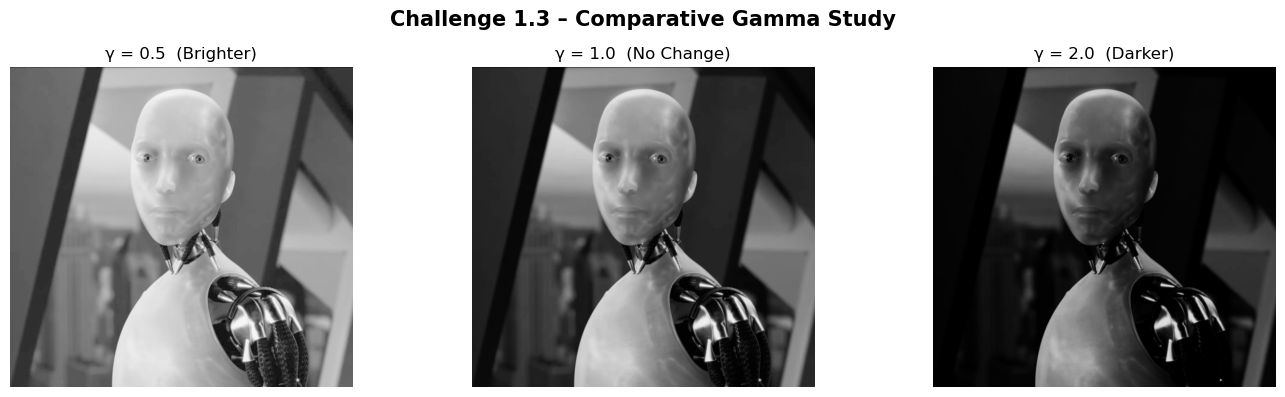

In [14]:
gamma_list = [0.5, 1.0, 2.0]
labels = ['γ = 0.5  (Brighter)', 'γ = 1.0  (No Change)', 'γ = 2.0  (Darker)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, gamma, label in zip(axes, gamma_list, labels):
    result = gamma_correction(test_image, gamma)
    ax.imshow(result, cmap='gray', vmin=0, vmax=255)
    ax.set_title(label, fontsize=12)
    ax.axis('off')

plt.suptitle('Challenge 1.3 – Comparative Gamma Study', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('challenge_1_3.png', dpi=120, bbox_inches='tight')
plt.show()

# Part 2 – Basic Intensity Transformations

### Challenge 2.1 – Image Negative

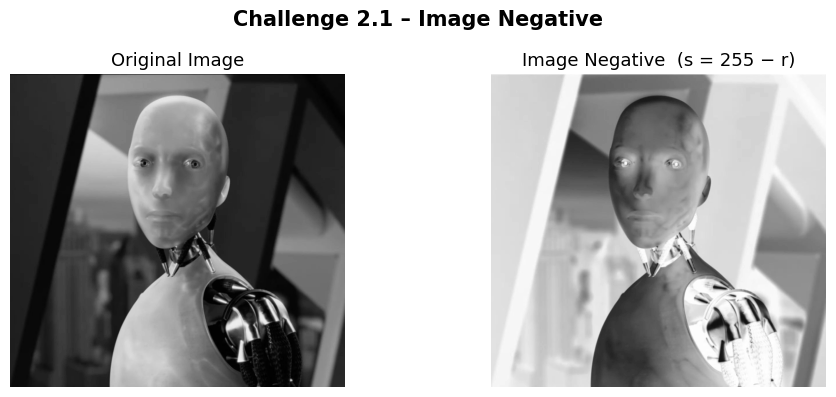

In [13]:
def image_negative(image):
    
    if not isinstance(image, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if image.dtype != np.uint8:
        raise ValueError("Image must be of dtype uint8.")

    L = 255  
    
    negative = np.empty_like(image)
    for idx in np.ndindex(image.shape):
        negative[idx] = L - image[idx]

    return negative.astype(np.uint8)

def image_negative_fast(image):
    """Vectorized version using the same formula: s = 255 - r."""
    if not isinstance(image, np.ndarray) or image.dtype != np.uint8:
        raise ValueError("Input must be a uint8 NumPy array.")
    return (255 - image.astype(np.int16)).astype(np.uint8)

neg_image = image_negative_fast(test_image)  

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(test_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image', fontsize=13)
axes[0].axis('off')

axes[1].imshow(neg_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Image Negative  (s = 255 − r)', fontsize=13)
axes[1].axis('off')

plt.suptitle('Challenge 2.1 – Image Negative', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('challenge_2_1.png', dpi=120, bbox_inches='tight')
plt.show()

### Challenge 2.2 – Intensity Range Mapping

Set pixel intensity range [A, B] to white (255).

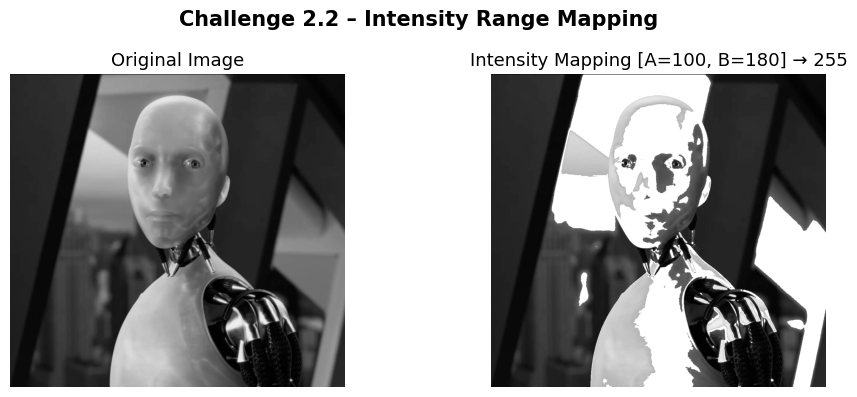

In [12]:
def intensity_range_mapping(image, A, B, fill_value=255):
    
    if not isinstance(image, np.ndarray) or image.dtype != np.uint8:
        raise ValueError("Image must be a uint8 NumPy array.")
    if not (0 <= A <= B <= 255):
        raise ValueError("A and B must satisfy 0 <= A <= B <= 255.")

    result = image.copy()
    mask = (image >= A) & (image <= B)
    result[mask] = fill_value
    return result

A, B = 100, 180
mapped = intensity_range_mapping(test_image, A, B)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(test_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image', fontsize=13)
axes[0].axis('off')

axes[1].imshow(mapped, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Intensity Mapping [A={A}, B={B}] → 255', fontsize=13)
axes[1].axis('off')

plt.suptitle('Challenge 2.2 – Intensity Range Mapping', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('challenge_2_2.png', dpi=120, bbox_inches='tight')
plt.show()

### Challenge 2.3 – Integrated Enhancement

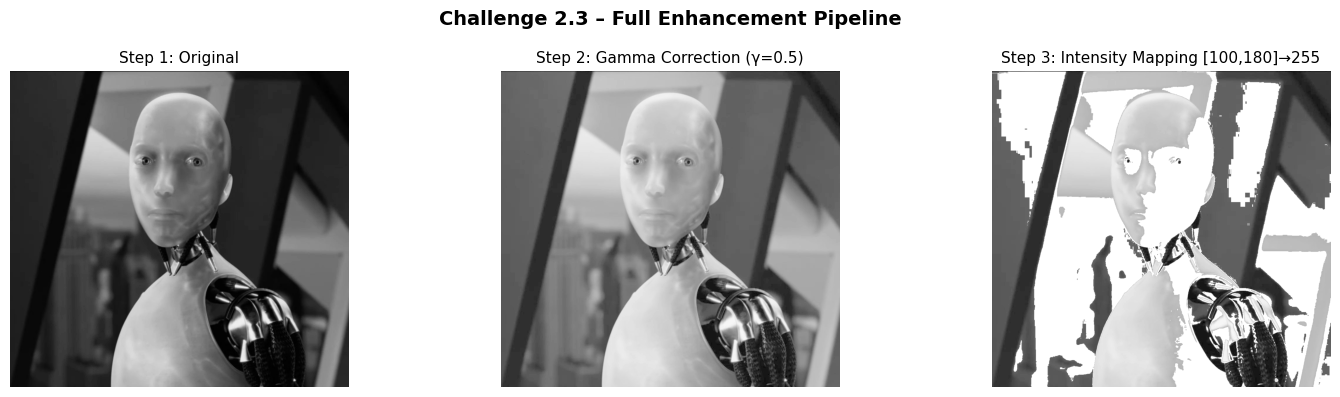

In [11]:
def enhancement_pipeline(image, gamma=0.5, A=100, B=180):
    
    # Original
    stage1 = image

    # Gamma correction
    stage2 = gamma_correction(stage1, gamma)

    # Intensity mapping
    stage3 = intensity_range_mapping(stage2, A, B)

    # Display all stages
    stages = [stage1, stage2, stage3]
    titles = [
        'Step 1: Original',
        f'Step 2: Gamma Correction (γ={gamma})',
        f'Step 3: Intensity Mapping [{A},{B}]→255'
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, stage, title in zip(axes, stages, titles):
        ax.imshow(stage, cmap='gray', vmin=0, vmax=255)
        ax.set_title(title, fontsize=11)
        ax.axis('off')

    plt.suptitle('Challenge 2.3 – Full Enhancement Pipeline', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('challenge_2_3.png', dpi=120, bbox_inches='tight')
    plt.show()
    return stage3


final_result = enhancement_pipeline(test_image, gamma=0.5, A=100, B=180)

# Part 3 – Advanced Optimization Challenge

### Challenge 3.1 – Performance & Robustness

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def _validate_image(image):
    
    if not isinstance(image, np.ndarray):
        raise TypeError(f"Expected np.ndarray, got {type(image).__name__}.")
    if image.dtype != np.uint8:
        raise ValueError(f"Image dtype must be uint8, got {image.dtype}.")
    if image.ndim not in (2, 3):
        raise ValueError("Image must be 2D (grayscale) or 3D (RGB/RGBA).")


def gamma_correction_v2(image, gamma):
    
    _validate_image(image)
    if not isinstance(gamma, (int, float)) or gamma <= 0:
        raise ValueError("Gamma must be a positive number.")

    lut = np.array([(i / 255.0) ** gamma * 255.0 for i in range(256)],
                   dtype=np.float64)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    
    return lut[image]


def image_negative_v2(image):
    _validate_image(image)
    return (255 - image.astype(np.int16)).astype(np.uint8)


def intensity_range_mapping_v2(image, A, B, fill_value=255):
    _validate_image(image)
    if not (0 <= A <= B <= 255):
        raise ValueError("Range must satisfy 0 <= A <= B <= 255.")

    result = image.copy()

    if image.ndim == 2:  # Grayscale
        mask = (image >= A) & (image <= B)
        result[mask] = fill_value
    else:  # RGB: apply per-channel independently
        for c in range(image.shape[2]):
            mask = (image[:, :, c] >= A) & (image[:, :, c] <= B)
            result[:, :, c][mask] = fill_value

    return result

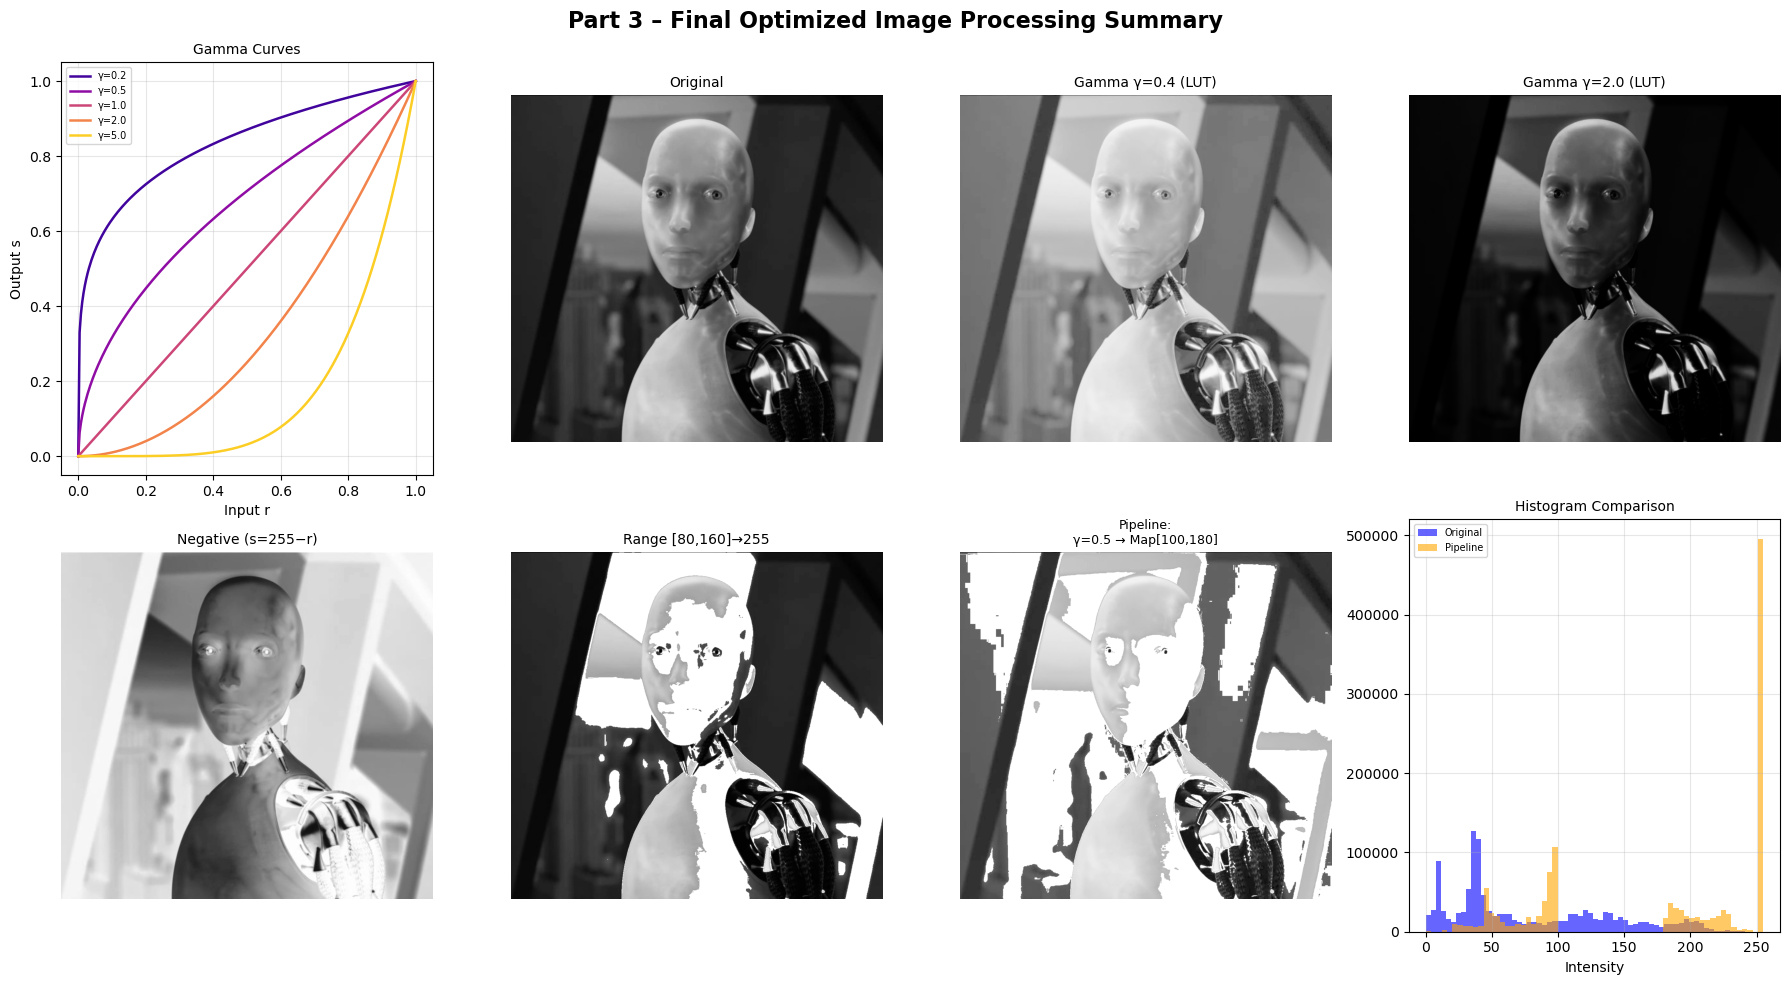

In [10]:
# FINAL COMBINED VISUALIZATION

def final_summary(image):
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('Part 3 – Final Optimized Image Processing Summary',
                 fontsize=16, fontweight='bold', y=0.98)

    # Gamma Curve Analysis 
    ax_curve = fig.add_subplot(2, 4, 1)
    r = np.linspace(0, 1, 256)
    gammas = [0.2, 0.5, 1.0, 2.0, 5.0]
    colors_curve = plt.cm.plasma(np.linspace(0.1, 0.9, len(gammas)))
    for g, c in zip(gammas, colors_curve):
        ax_curve.plot(r, np.power(r, g), label=f'γ={g}', color=c, lw=1.8)
    ax_curve.set_title('Gamma Curves', fontsize=10)
    ax_curve.set_xlabel('Input r')
    ax_curve.set_ylabel('Output s')
    ax_curve.legend(fontsize=7)
    ax_curve.grid(True, alpha=0.3)

    # Original 
    ax_orig = fig.add_subplot(2, 4, 2)
    ax_orig.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax_orig.set_title('Original', fontsize=10)
    ax_orig.axis('off')

    # Gamma 0.4
    img_gamma = gamma_correction_v2(image, 0.4)
    ax_g = fig.add_subplot(2, 4, 3)
    ax_g.imshow(img_gamma, cmap='gray', vmin=0, vmax=255)
    ax_g.set_title('Gamma γ=0.4 (LUT)', fontsize=10)
    ax_g.axis('off')

    # Gamma 2.0 
    img_gamma2 = gamma_correction_v2(image, 2.0)
    ax_g2 = fig.add_subplot(2, 4, 4)
    ax_g2.imshow(img_gamma2, cmap='gray', vmin=0, vmax=255)
    ax_g2.set_title('Gamma γ=2.0 (LUT)', fontsize=10)
    ax_g2.axis('off')

    #  Negative 
    img_neg = image_negative_v2(image)
    ax_neg = fig.add_subplot(2, 4, 5)
    ax_neg.imshow(img_neg, cmap='gray', vmin=0, vmax=255)
    ax_neg.set_title('Negative (s=255−r)', fontsize=10)
    ax_neg.axis('off')

    # Intensity Mapping 
    img_mapped = intensity_range_mapping_v2(image, 80, 160)
    ax_map = fig.add_subplot(2, 4, 6)
    ax_map.imshow(img_mapped, cmap='gray', vmin=0, vmax=255)
    ax_map.set_title('Range [80,160]→255', fontsize=10)
    ax_map.axis('off')

    # Full Pipeline Output 
    img_pipeline = intensity_range_mapping_v2(gamma_correction_v2(image, 0.5), 100, 180)
    ax_pipe = fig.add_subplot(2, 4, 7)
    ax_pipe.imshow(img_pipeline, cmap='gray', vmin=0, vmax=255)
    ax_pipe.set_title('Pipeline:\nγ=0.5 → Map[100,180]', fontsize=9)
    ax_pipe.axis('off')

    #  Histogram Comparison 
    ax_hist = fig.add_subplot(2, 4, 8)
    ax_hist.hist(image.ravel(), bins=64, alpha=0.6, color='blue', label='Original')
    ax_hist.hist(img_pipeline.ravel(), bins=64, alpha=0.6, color='orange', label='Pipeline')
    ax_hist.set_title('Histogram Comparison', fontsize=10)
    ax_hist.set_xlabel('Intensity')
    ax_hist.legend(fontsize=7)
    ax_hist.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('final_summary.png', dpi=120, bbox_inches='tight')
    plt.show()


final_summary(test_image)